<a href="https://colab.research.google.com/github/BintangPancahaya/PemMes_2026/blob/main/JS04/JS04_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Deskripsi Dataset
Dataset **Medical Cost Personal** (`insurance.csv`) berisi 1338 data individu beserta biaya medis yang ditagihkan asuransi kesehatan.

| Variabel | Tipe | Keterangan |
|---|---|---|
| `age` | numerik | Usia penerima asuransi |
| `sex` | kategorikal | Jenis kelamin (male/female) |
| `bmi` | numerik | Body Mass Index (kg/m²) |
| `children` | numerik | Jumlah tanggungan anak |
| `smoker` | kategorikal | Perokok atau bukan (yes/no) |
| `region` | kategorikal | Wilayah tempat tinggal (northeast, northwest, southeast, southwest) |
| `charges` | numerik | **Target**: biaya medis personal (USD) |

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Ukuran data: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
               age          bmi     children       charges
count  1338.00

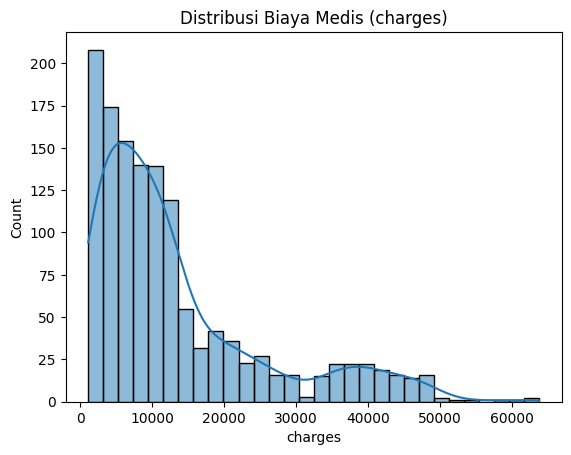

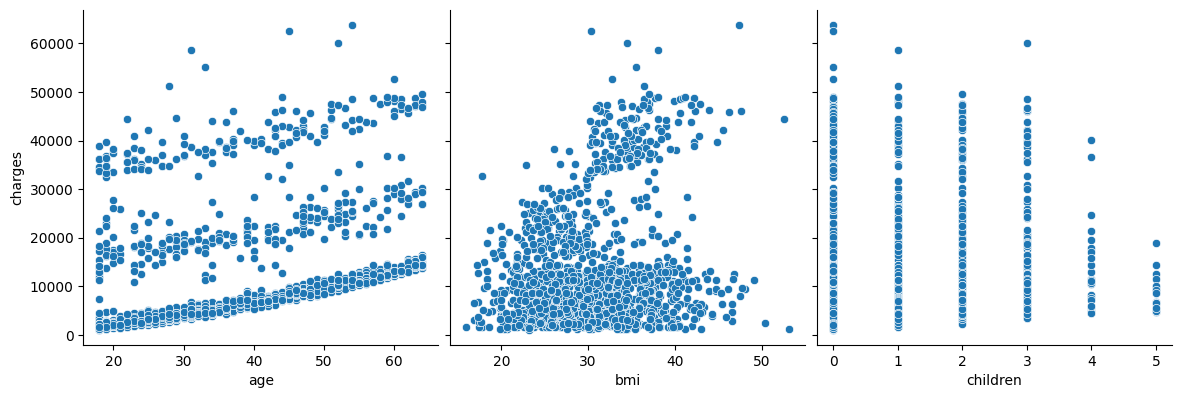

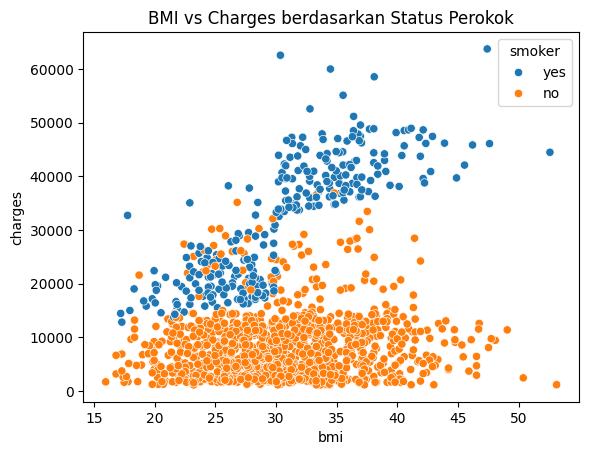

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400         0           1                 0   
1   18  33.770         1   1725.55230         1           0                 0   
2   28  33.000         3   4449.46200         1           0                 0   
3   33  22.705         0  21984.47061         1           0                 1   
4   32  28.880         0   3866.85520         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


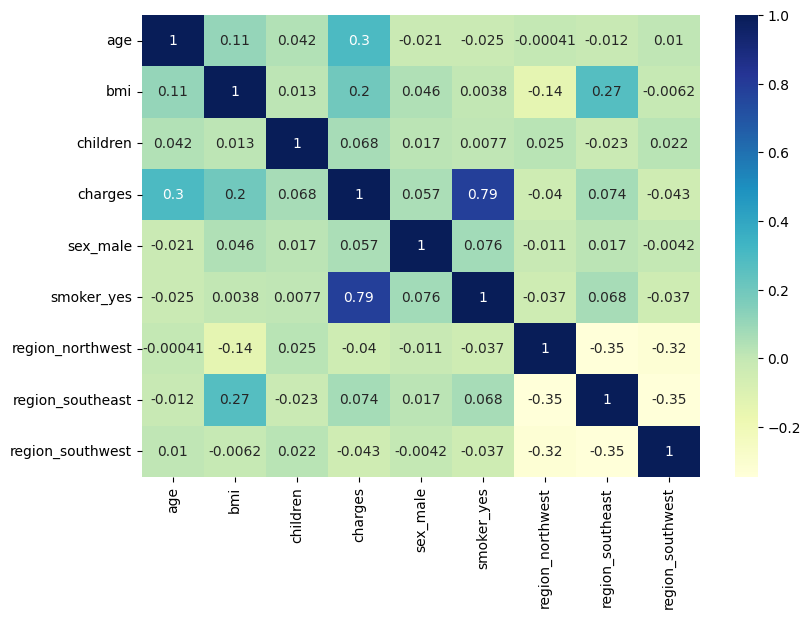

Data latih: (936, 8) | Data uji: (402, 8)
              Fitur  Koefisien
4        smoker_yes   0.782880
0               age   0.301693
1               bmi   0.148296
2          children   0.046957
3          sex_male  -0.000003
5  region_northwest  -0.026776
6  region_southeast  -0.034930
7  region_southwest  -0.056606
Intercept: -1.8442109578557806e-16
=== Evaluasi Multiple Linear Regression ===
MAE      : 3943.237703947303
MSE      : 32345536.74852545
RMSE     : 5687.313667147738
R-squared: 0.7772310511733103
=== Evaluasi SVR (default) ===
MAE      : 2410.2604402985594
MSE      : 18026447.80335132
RMSE     : 4245.756446541808
R-squared: 0.8758489352193288
Parameter terbaik: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
R-squared CV terbaik: 0.8144704061779906
=== Evaluasi SVR (setelah tuning) ===
MAE      : 2520.4310707776717
MSE      : 18279451.337326854
RMSE     : 4275.447501411619
R-squared: 0.8741064589156782
                        Model          MAE           MSE  

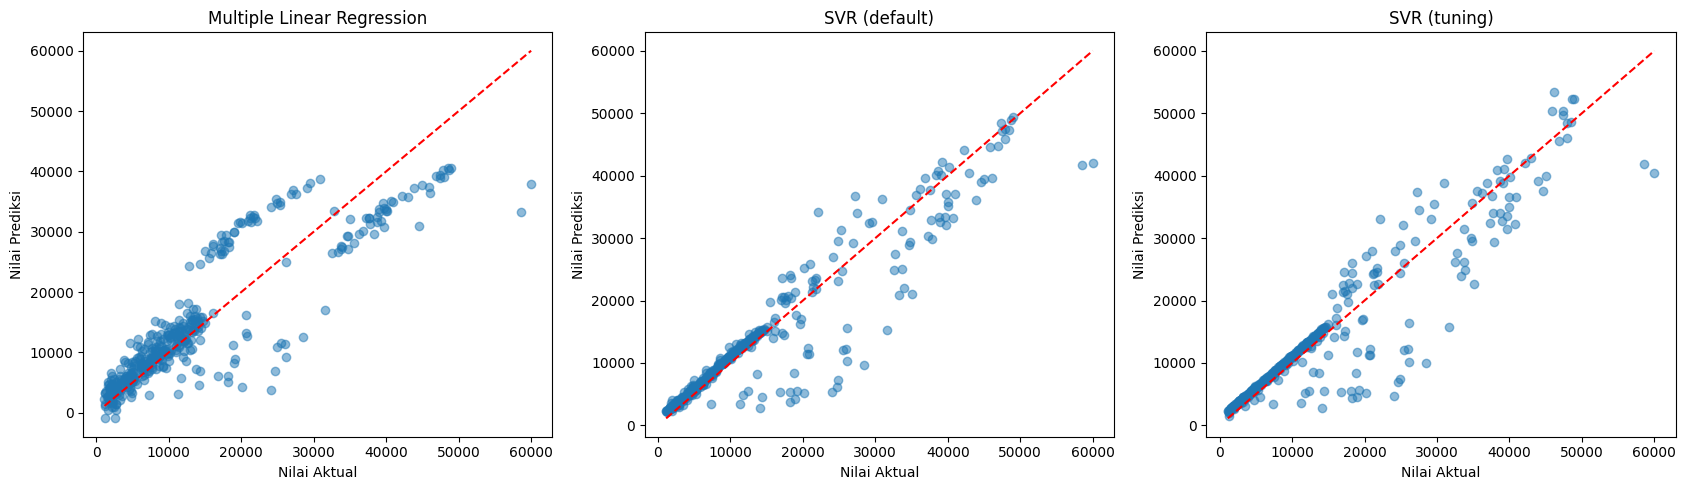

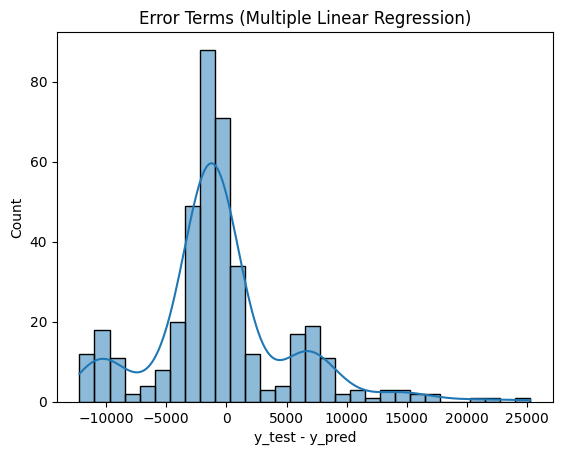

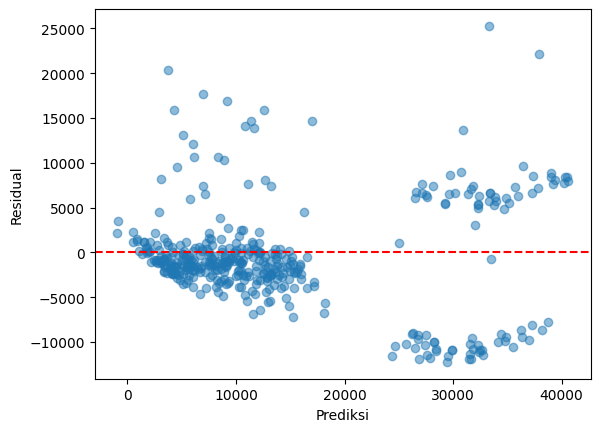

In [1]:
# ==========================================================
# Praktikum Regresi: Multiple Linear Regression & SVR
# Dataset: Medical Cost Personal (insurance.csv)
# ==========================================================

# ---------- Langkah 1: Import Library ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Langkah 2: Baca Data ----------
# Pastikan file insurance.csv berada pada direktori yang sama
data = pd.read_csv('insurance.csv')

# ---------- Langkah 3: Pemahaman Terhadap Data ----------
print(data.head())
print("Ukuran data:", data.shape)
data.info()
print(data.describe())
print("Missing value:\n", data.isnull().sum())

# ---------- Langkah 4: Visualisasi Data ----------
# Distribusi target
sns.histplot(data['charges'], bins=30, kde=True)
plt.title('Distribusi Biaya Medis (charges)')
plt.show()

# Hubungan variabel numerik dengan target
sns.pairplot(data, x_vars=['age', 'bmi', 'children'], y_vars='charges',
             height=4, aspect=1, kind='scatter')
plt.show()

# Pengaruh perokok terhadap biaya medis
sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker')
plt.title('BMI vs Charges berdasarkan Status Perokok')
plt.show()

# ---------- Langkah 5: Encoding Variabel Kategorikal ----------
# sex, smoker, region berupa teks sehingga diubah menjadi angka (one-hot encoding)
data_enc = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
print(data_enc.head())

# Visualisasi korelasi dengan heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(data_enc.corr(), cmap="YlGnBu", annot=True)
plt.show()

# ---------- Langkah 6: Menentukan Variabel Bebas (X) dan Target (y) ----------
X = data_enc.drop('charges', axis=1)
y = data_enc['charges']

# ---------- Langkah 7: Pembagian Data Latih dan Data Uji (7:3) ----------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)
print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)

# ---------- Langkah 8: Feature Scaling ----------
# fit hanya pada data latih, lalu transform pada data uji
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X_train_sc = sc_X.fit_transform(X_train)
X_test_sc = sc_X.transform(X_test)
y_train_sc = sc_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# ---------- Langkah 9: Multiple Linear Regression ----------
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_sc, y_train_sc)

# Koefisien model
koefisien = pd.DataFrame({'Fitur': X.columns, 'Koefisien': lr.coef_})
print(koefisien.sort_values('Koefisien', ascending=False))
print("Intercept:", lr.intercept_)

# Prediksi data uji lalu kembalikan ke skala asli
y_pred_lr = sc_y.inverse_transform(lr.predict(X_test_sc).reshape(-1, 1)).ravel()

# ---------- Langkah 10: Evaluasi Multiple Linear Regression ----------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Evaluasi Multiple Linear Regression ===")
print("MAE      :", mae_lr)
print("MSE      :", mse_lr)
print("RMSE     :", rmse_lr)
print("R-squared:", r2_lr)

# ---------- Langkah 11: Support Vector Regression (SVR) ----------
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_sc, y_train_sc)
y_pred_svr = sc_y.inverse_transform(svr.predict(X_test_sc).reshape(-1, 1)).ravel()

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("=== Evaluasi SVR (default) ===")
print("MAE      :", mae_svr)
print("MSE      :", mse_svr)
print("RMSE     :", rmse_svr)
print("R-squared:", r2_svr)

# ---------- Langkah 12: Hyperparameter Tuning SVR ----------
from sklearn.model_selection import GridSearchCV
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5]
}
grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2')
grid.fit(X_train_sc, y_train_sc)

print("Parameter terbaik:", grid.best_params_)
print("R-squared CV terbaik:", grid.best_score_)

svr_best = grid.best_estimator_
y_pred_best = sc_y.inverse_transform(svr_best.predict(X_test_sc).reshape(-1, 1)).ravel()

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("=== Evaluasi SVR (setelah tuning) ===")
print("MAE      :", mae_best)
print("MSE      :", mse_best)
print("RMSE     :", rmse_best)
print("R-squared:", r2_best)

# ---------- Langkah 13: Perbandingan Model ----------
hasil = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR (default)', 'SVR (tuning)'],
    'MAE': [mae_lr, mae_svr, mae_best],
    'MSE': [mse_lr, mse_svr, mse_best],
    'RMSE': [rmse_lr, rmse_svr, rmse_best],
    'R-squared': [r2_lr, r2_svr, r2_best]
})
print(hasil)

# ---------- Langkah 14: Visualisasi Hasil Prediksi ----------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, judul, pred in zip(axes,
                           ['Multiple Linear Regression', 'SVR (default)', 'SVR (tuning)'],
                           [y_pred_lr, y_pred_svr, y_pred_best]):
    ax.scatter(y_test, pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(judul)
    ax.set_xlabel('Nilai Aktual')
    ax.set_ylabel('Nilai Prediksi')
plt.tight_layout()
plt.show()

# ---------- Langkah 15: Analisis Residual ----------
res = y_test - y_pred_lr
sns.histplot(res, bins=30, kde=True)
plt.title('Error Terms (Multiple Linear Regression)')
plt.xlabel('y_test - y_pred')
plt.show()

plt.scatter(y_pred_lr, res, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Prediksi')
plt.ylabel('Residual')
plt.show()